### Log odds

In [1]:
import numpy as np
from skimage.draw import line




# mexendo atualmente
LOG_ODDS_MIN = -10.0
LOG_ODDS_MAX = 10.0
# --- PARÂMETROS DO MAPA ---
MAP_RESOLUTION = 0.1  # 10 cm por célula (problema quando muda a resolucao)
MAP_SIZE_X = 10.0      # metros
MAP_SIZE_Y = 10.0      # metros
MAP_ORIGIN_X = -5.0    # Canto inferior esquerdo X
MAP_ORIGIN_Y = -5.0    # Canto inferior esquerdo Y
nrows = int(MAP_SIZE_Y / MAP_RESOLUTION)
ncols = int(MAP_SIZE_X / MAP_RESOLUTION)
MAX_SCAN_DISTANCE = 5.0

def world_to_grid_xy(wx, wy):
    
    # Converte mundo (x,y) [m] -> índice de célula (ix, iy)
    # origem está no centro do mapa 0,0
    
    ix = int((wx - MAP_ORIGIN_X) / MAP_RESOLUTION)
    iy = int((wy - MAP_ORIGIN_Y) / MAP_RESOLUTION)
    
    # ix = int((ncols / 2) + (wx / cell_size)) # parentezes modificado, caso tenha problema rever
    # iy = int((nrows / 2) + (wy / cell_size))

    if 0 <= ix < ncols and 0 <= iy < nrows:
        return ix, iy
    return None, None




MAX_RANGE_THRESHOLD = MAX_SCAN_DISTANCE * 0.99
# Calculo do log_odds (explicar no video)
def update_map_log_odds(log_odds_map, robot_pos, laser_data, step, last_seen,
                        l_occ=0.2, l_free=-0.7):
    
    x, y, theta_r = robot_pos[0], robot_pos[1], robot_pos[2]
    x_Grid, y_Grid = world_to_grid_xy(x, y)
    
    if x_Grid is None or y_Grid is None:
        return log_odds_map, last_seen

    # Limiar para considerar uma célula como "fortemente ocupada"
    # (Não apague células acima deste valor)
    L_OCC_THRESHOLD = 3 
    L_FREE_THRESHOLD = -3
    
    
    for d, ang in laser_data:
        if d <= 0.01: 
            continue

        global_ang = theta_r + ang
        posi_x = x + d * np.cos(global_ang)
        posi_y = y + d * np.sin(global_ang)
        posi_xGrid, posi_yGrid = world_to_grid_xy(posi_x, posi_y)
        
        if posi_xGrid is None or posi_yGrid is None:
            continue
        
        rr, cc = line(y_Grid, x_Grid, posi_yGrid, posi_xGrid)
        
        if len(rr) <= 1:
            continue

        # --- LÓGICA DE ATUALIZAÇÃO CORRIGIDA ---

        # 1. Obter todas as células do feixe (exceto a do robô)
        beam_rows, beam_cols = rr[1:], cc[1:]

        # 2. Aplicar 'livre' (l_free) ao longo do feixe, EXCETO no ponto final
        if len(beam_rows) > 1:
            path_rows, path_cols = beam_rows[:-1], beam_cols[:-1]
            
            # Verificar o estado atual dessas células
            current_log_odds = log_odds_map[path_rows, path_cols]
            
            # Criar uma máscara de células que NÃO estão fortemente ocupadas
            free_or_unknown_mask = current_log_odds < L_OCC_THRESHOLD
            
            # Aplicar 'l_free' APENAS a essas células
            rows_to_free = path_rows[free_or_unknown_mask]
            cols_to_free = path_cols[free_or_unknown_mask]
            log_odds_map[rows_to_free, cols_to_free] += l_free

        # 3. Tratar o PONTO FINAL (a última célula do feixe)
        end_row, end_col = beam_rows[-1], beam_cols[-1]
        
        if d < MAX_RANGE_THRESHOLD:
            # if log_odds_map[end_row, end_col] > L_FREE_THRESHOLD:
                log_odds_map[end_row, end_col] += l_occ
        else:
            # Feixe de Max Range -> Marcar ponto final como LIVRE
            # (Também checando para não apagar um obstáculo)
            # if log_odds_map[end_row, end_col] < L_OCC_THRESHOLD:
                log_odds_map[end_row, end_col] += l_free

        # 4. Atualizar o tempo de visão de todo o feixe
        last_seen[rr, cc] = step

    # Clamp para estabilidade
    np.clip(log_odds_map, LOG_ODDS_MIN, LOG_ODDS_MAX, out=log_odds_map)
    return log_odds_map, last_seen


### Controle


In [11]:
import numpy as np


class Controlador:
    
    def __init__(self):
        self.state = "SEGUINDO"
        self.last_posi = None
        self.last_time = 0.0
        self.tempo_preso = 0.0
        
        self.alvo_yaw = None
        self.tempo_em_frente = 0.0
        self.tempo_escape_re = 0.0
        
        self.ultima_direita = 0.5
        
        
    def controle_wall_following_com_escape(self, sim, robot, laser_data, r, L):
        
        
        # CTE limites
        max_vel_linear = 1.0
        max_vel_angular = np.deg2rad(90)
        
        # CTE escape
        intervalo_checagem = 1.0
        movimento_min = 0.1     # movimento para nao ser considerado preso
        tempo_limite = 5.0      # tempo para ser considerado preso
        
        tempo_re = 1.5
        vel_re = -0.2
        
        tempo_angulo = np.deg2rad(90)
        vel_angulo = np.deg2rad(45)

        tempo_em_frente = 1.5   
        vel_em_frente = 0.3      

        # CTE seguindo parede
        distancia_desejada = 0.4
        ganho_angular = 2
        vel_linear_fixa = 1.0
        
        # --- MODIFICADO --- Limite frontal menor para reagir mais perto
        limite_frontal = 0.6
        zona_erro = 0.05
        distancia_sem_parede = 2.0
        
        
        
        
    
        # Pegando informações do robo via sim
        time = sim.getSimulationTime()
        posi = sim.getObjectPosition(robot, -1)
        ori  = sim.getObjectOrientation(robot, -1)
        yaw  = ori[2] 

        # Verificacao se esta preso
        if self.state == "SEGUINDO":
            
            if self.last_posi is None:
                self.last_posi = posi
                self.last_time = time
            
            ultima_veirificao = time - self.last_time
            
            if ultima_veirificao > intervalo_checagem:
                dist_moved = np.linalg.norm(np.array(posi) - np.array(self.last_posi))
                
                if dist_moved < movimento_min:
                    self.tempo_preso += ultima_veirificao
                else:
                    self.tempo_preso = 0.0
                
                self.last_posi = posi
                self.last_time = time

            
            if self.tempo_preso > tempo_limite:
                print(f"Ativando Ré")
                self.state = "RE"
                self.tempo_escape_re = time + tempo_re
                self.tempo_preso = 0.0
                

        # inicioando a re
        if self.state == "RE":
            if time < self.tempo_escape_re:
                v_cmd = vel_re
                w_cmd = 0.0
            else:
                print("Ré de escape completa. Iniciando giro.")
                self.state = "GIRO"
                
                alvo_yaw_semNormalizaco = yaw + tempo_angulo
                self.alvo_yaw = np.arctan2(np.sin(alvo_yaw_semNormalizaco), np.cos(alvo_yaw_semNormalizaco))
                
                # robo para
                v_cmd = 0.0
                w_cmd = 0.0
                
        
        # rotaciona 90 graus a esquerda        
        elif self.state == "GIRO":
            
            erro_yaw = self.alvo_yaw - yaw
            erro_yaw = np.arctan2(np.sin(erro_yaw), np.cos(erro_yaw))
            
            if abs(erro_yaw) < np.deg2rad(5):
                print("Giro de escape completo.")
                self.state = "EM_FRENTE"
                self.tempo_em_frente = time + tempo_em_frente
                v_cmd = 0.0
                w_cmd = 0.0
            else:
                v_cmd = 0.0
                w_cmd = vel_angulo

        # seguindo em Frente
        elif self.state == "EM_FRENTE":
            
            if time < self.tempo_em_frente:
                v_cmd = vel_em_frente
                w_cmd = 0.0
            else:
                print("Movimento de escape completo. Retornando ao Wall Following.")
                self.state = "SEGUINDO"
                self.last_posi = None
                v_cmd = 0.0
                w_cmd = 0.0
                
                
                
        # Seguindo parede        
        elif self.state == "SEGUINDO":
            
            # # verificar qual o caso correto
            # if isinstance(laser_data, dict) and "ranges" in laser_data:
            #     ranges = np.array(laser_data["ranges"], dtype=float)
            # else:
                # ranges = np.array(laser_data[:, 1], dtype=float)
            # ranges = np.array(laser_data["ranges"], dtype=float)
            ranges = np.array(laser_data[:, 1], dtype=float)
            ranges = np.nan_to_num(ranges, posinf=100.0, neginf=0.0)
            num = len(ranges)
            
            if num == 0:
                v_cmd, w_cmd = 0.0, 0.0
            else:
                c = num // 2 # Meio da visao
                
                fatia_frente = int(num * 0.08)
                frente_ranges = ranges[c - fatia_frente : c + fatia_frente]
                dist_frente = np.min(frente_ranges) if frente_ranges.size > 0 else 100.0

                fatia_direita = int(num * 0.10)
                direita_ranges = ranges[0 : fatia_direita]
                validas = direita_ranges[direita_ranges < distancia_sem_parede]
                
                if len(validas) > 0:
                    dist_direita = np.min(validas)
                else:
                    dist_direita = distancia_sem_parede
                
                # limpeza de ruido na idendificao da parede
                if dist_direita > self.ultima_direita * 1.5:
                    dist_direita = self.ultima_direita * 1.1
                self.ultima_direita = dist_direita



                if dist_frente < limite_frontal:
                    
                    fator_proximidade = dist_frente / limite_frontal # normalizacao
                    
                    v_cmd = vel_linear_fixa * fator_proximidade
                    v_cmd = max(v_cmd, 0.05)
                    
                    fator_virada = 1.0 - fator_proximidade 
                    w_cmd = max_vel_angular * fator_virada 
                
                
                elif dist_direita > distancia_sem_parede:
                    v_cmd = 0.4
                    w_cmd = 0.0 
                else:
                    erro = distancia_desejada - dist_direita
                    if abs(erro) < zona_erro:
                        erro = 0.0
                    w_cmd = ganho_angular * erro
                    fator_reducao = 1.0 - (abs(w_cmd) / max_vel_angular)
                    v_cmd = vel_linear_fixa * fator_reducao
                    v_cmd = max(v_cmd, 0.1)


        # Limitador de velocidade
        v_cmd = np.clip(v_cmd, -max_vel_linear, max_vel_linear)
        w_cmd = np.clip(w_cmd, -max_vel_angular, max_vel_angular)

        # Cinematica inversa -> Nao Holonomico
        w_r = (v_cmd/r) + ((w_cmd * L) / (2.0 * r))
        w_l = (v_cmd/r) - ((w_cmd * L) / (2.0 * r))
        
        
        return w_l, w_r
            


### Hokuyo

In [3]:
import numpy as np
import math
import time

# codigo do moodle Iago

class HokuyoSensorSim(object): 
    _sim = None
    
    _base_name = "" 

    _angles_lua = np.empty(0) 
    _is_initialized_angles = False 
    ANGLE_SIGNAL = 'signal.hokuyo_angle_data' 
    
    _base_obj = None 
    _is_range_data = True
    _vision_sensors_obj = []

    def __init__(self, sim, base_name, is_range_data=True):
        self._sim = sim
        self._base_name = base_name
        self._is_range_data = is_range_data

        if "fastHokuyo" not in base_name:
            raise ValueError(
                f"ERR: fastHokuyo must be in the base object name. Ex: `/kobuki/fastHokuyo`"
            )

        self._base_obj = sim.getObject(base_name)
        if self._base_obj == -1:
            raise ValueError(
                f"ERR: base_obj ({self._base_obj}) is not a valid name in the simulation"
            )

        self._vision_sensors_obj = [
            sim.getObject(f'{base_name}/fastHokuyo_sensor1'),
            sim.getObject(f'{base_name}/fastHokuyo_sensor2'),
        ]

        if any(obj == -1 for obj in self._vision_sensors_obj):
            raise ValueError(
                f"ERR: the _vision_sensors_obj names are not valid in the simulation"
            )

    def get_is_range_data(self) -> bool:
        return self._is_range_data

    def set_is_range_data(self, is_range_data: bool) -> None:
        self._is_range_data = is_range_data

    def _initialize_angles_from_lua(self):

        # Essas variáveis agora são utilizadas apenas quando os valores do laser 
        # não são desempacotados diretamente do sensor, como um fallback em caso de falha
        angle_min = -120 * math.pi / 180
        angle_increment = (240 / 684) * math.pi / 180
        total_steps = 684
        
        for i in range(15):
            try:
                if self._vision_sensors_obj and self._vision_sensors_obj[0] != -1:
                    self._sim.readVisionSensor(self._vision_sensors_obj[0]) 

                angles_packed = self._sim.getBufferProperty(self._sim.handle_scene, self.ANGLE_SIGNAL, {'noError' : True})
                
                if angles_packed:
                    self._angles_lua = np.array(self._sim.unpackFloatTable(angles_packed))
                    self._is_initialized_angles = True
                    print(f"Precise sensor angles read on attempt {i+1} ({self._angles_lua.size} laser beam readings)")
                    return True
                
                time.sleep(0.01)

            except Exception as e:
                pass 
                
        self._angles_lua = np.arange(angle_min, angle_min + total_steps * angle_increment, angle_increment)
        self._is_initialized_angles = True
        print("ALERT: Communication via buffer property failed. Using approximation. Map may be blurred.")
        return False

    def getSensorData(self):
        
        if not self._is_initialized_angles:
            self._initialize_angles_from_lua()
        
        sensor_data = []
        angle_idx = 0
        angles_to_use = self._angles_lua
        
        if angles_to_use.size == 0:
            return np.empty((0, 2))
        
        for vision_sensor in self._vision_sensors_obj:
            
            result = self._sim.readVisionSensor(vision_sensor)
            if not isinstance(result, (list, tuple)) or len(result) != 3: continue 
                
            r, t, u = result
            if u:
                for j in range(int(u[1])): 
                    for k in range(int(u[0])): 
                        w_idx = 2 + 4 * (j * int(u[0]) + k)
                        v_dist = u[w_idx + 3] 
                        if angle_idx < angles_to_use.size:
                            current_angle = angles_to_use[angle_idx]
                            sensor_data.append([current_angle, v_dist])
                            angle_idx += 1
                        else:
                            break 
                    if angle_idx >= angles_to_use.size: break

        return np.array(sensor_data) if sensor_data else np.empty((0, 2))
    
def transform_laser_to_global(laser_data, robot_pos, robot_ori):

    x_r, y_r = robot_pos[0], robot_pos[1]
    theta_r = robot_ori[2]  # orientação em torno de z

    global_points = []

    

    for ang, dist in laser_data:
        if dist > 0.01 and dist < 5:
            # coordenadas no robô
            x_local = dist * np.cos(ang)
            y_local = dist * np.sin(ang)

            # transformação para global
            x_global = x_r + x_local*np.cos(theta_r) - y_local*np.sin(theta_r)
            y_global = y_r + x_local*np.sin(theta_r) + y_local*np.cos(theta_r)

            global_points.append([x_global, y_global])

    return global_points

### Main

Program ended


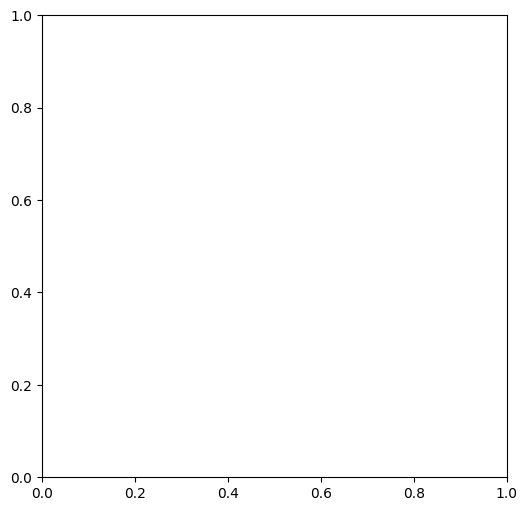

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import ListedColormap

from coppeliasim_zmqremoteapi_client import RemoteAPIClient

# funcoes em outros arquivos
# import HokuyoSensorSim
# import controleWallFollowing
# import logOdds


def pixel_to_world(x_px, y_px, img_size=64, world_size=10):
        scale = world_size / img_size
        x_world = ((x_px - img_size/2) * scale)
        y_world = (-(y_px - img_size/2) * scale) 
        return x_world, y_world


MAP_RESOLUTION = 0.1  # divizao das celulas
MAP_SIZE_X = 10.0     
MAP_SIZE_Y = 10.0     


MAP_ORIGIN_X = -5.0    # Canto inferior esquerdo X
MAP_ORIGIN_Y = -5.0    # Canto inferior esquerdo Y
nrows = int(MAP_SIZE_Y / MAP_RESOLUTION)
ncols = int(MAP_SIZE_X / MAP_RESOLUTION)
MAX_SCAN_DISTANCE = 5.0



LOG_ODDS_MIN = -5.0
LOG_ODDS_MAX = 5.0

map_size_m = 10.0
cell_size = 0.1                      # m por célula
ncols = int(map_size_m / cell_size)  # cols = eixo X
nrows = int(map_size_m / cell_size)  # rows = eixo Y
grid_origin = np.array([-map_size_m/2, -map_size_m/2])  # world coord do canto inferior esquerdo da célula (0,0)


world = pixel_to_world(30,34,100,10)
goal_position = np.array([world[0], world[1]])


L = 0.381  
r = 0.0975 

client = RemoteAPIClient()
sim = client.require("sim")

robotname = "kobuki"
robot = sim.getObject(f'/{robotname}')
l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')

# pega valores do hokuyo
hokuyo = HokuyoSensorSim(sim, f"/{robotname}/fastHokuyo") 


cmap_vis = ListedColormap(['#808080', '#FFFFFF', '#000000'])
N_LASER_POINTS_PLOT = 1000
map_extent = [MAP_ORIGIN_X, MAP_ORIGIN_X + MAP_SIZE_X, 
              MAP_ORIGIN_Y, MAP_ORIGIN_Y + MAP_SIZE_Y]



hist = []            
laser_global = []    


log_odds_map = np.zeros((nrows, ncols))
last_seen = np.zeros_like(log_odds_map)


# define as cores do grid
cmap = ListedColormap(["gray", "white", "black"])




robot_path_world = [] 

LIMITE_TEMPO_SIM = 20 * 60
step = 0


contorle = Controlador()

plt.ion()
fig, ax = plt.subplots(figsize=(6,6))

while  sim.getSimulationState() != sim.simulation_stopped:
    current_sim_time = sim.getSimulationTime()

    sim.step()
    step +=1

    if step > 1000:
        print(f"Numero de passos maximo atingido. Parando a simulação.")
        break

    pos = sim.getObjectPosition(robot, sim.handle_world)
    ori = sim.getObjectOrientation(robot, sim.handle_world)
    
    
    hist.append([pos[0], pos[1]])
    
    laser_data = hokuyo.getSensorData()
    laser_global.extend(transform_laser_to_global(laser_data, pos, ori))

    robot_pos = [pos[0], pos[1], ori[2]]
    
    
    laser_data_swapped = [[d, a] for a, d in laser_data]
        
    log_odds_map, last_seen = update_map_log_odds(
        log_odds_map,
        robot_pos,
        laser_data_swapped,
        step,
        last_seen)
    
    
    # salvar rastro do robo
    robot_path_world.append((robot_pos[0], robot_pos[1]))
    
    #controlador do robo
    wl, wr = contorle.controle_wall_following_com_escape(sim, robot, laser_data, r, L)
    
    # passa velocidade angular para roda
    sim.setJointTargetVelocity(l_wheel, wl)
    sim.setJointTargetVelocity(r_wheel, wr)

#     # # frequencia de atualizacao do mapa
    if step % 25 == 0:
    
        print("Gerando Plot 2 (Mapa de Grid)...")

        # Converter log-odds para probabilidade (sua fórmula está correta)
        # 'log_odds_map' foi criada e atualizada no seu loop 'while'
        prob = 1.0 / (1.0 + np.exp(-log_odds_map)) 

        # Criar mapa visual (0=desconhecido, 1=livre, 2=ocupado)
        grid_vis = np.zeros_like(prob, dtype=np.uint8) # 0 = desconhecido
        grid_vis[prob < 0.45] = 1 # 1 = livre (branco)
        grid_vis[prob > 0.55] = 2 # 2 = ocupado (preto)

        # Definir um colormap: 0=cinza, 1=branco, 2=preto
        # (Substitui a variável 'cmap' indefinida)
        cmap = ListedColormap(['#808080', '#FFFFFF', '#000000'])

        plt.ioff()
        fig2, ax2 = plt.subplots(figsize=(7,7))

        # Definir a 'extent' usando as variáveis de configuração do mapa
        # (Substitui 'grid_origin', 'ncols', 'cell_size')
        extent = [MAP_ORIGIN_X, MAP_ORIGIN_X + MAP_SIZE_X, 
                MAP_ORIGIN_Y, MAP_ORIGIN_Y + MAP_SIZE_Y]
                
        ax2.imshow(grid_vis, origin='lower', cmap=cmap, extent=extent, vmin=0, vmax=2)

        # Plotar a trajetória (usando 'hist' ao invés de 'robot_path_world')
        if hist:
            xs, ys = zip(*hist)
            ax2.plot(xs, ys, color='blue', linewidth=1, label="Trajetória")
            ax2.plot(xs[-1], ys[-1], 'ro', markersize=5, label="Fim") # Ponto final

        # (Removi ax2.arrow() pois 'robot_pos' não está disponível aqui,
        # e o ponto final vermelho já marca a posição final)

        ax2.set_title("Mapa Final Explorado")
        ax2.set_xlabel("X (m)")
        ax2.set_ylabel("Y (m)")
        ax2.set_aspect('equal')
        ax2.legend()
        plt.show()
        


# parar sim
sim.stopSimulation()
print('Program ended')

Precise sensor angles read on attempt 1 (684 laser beam readings)


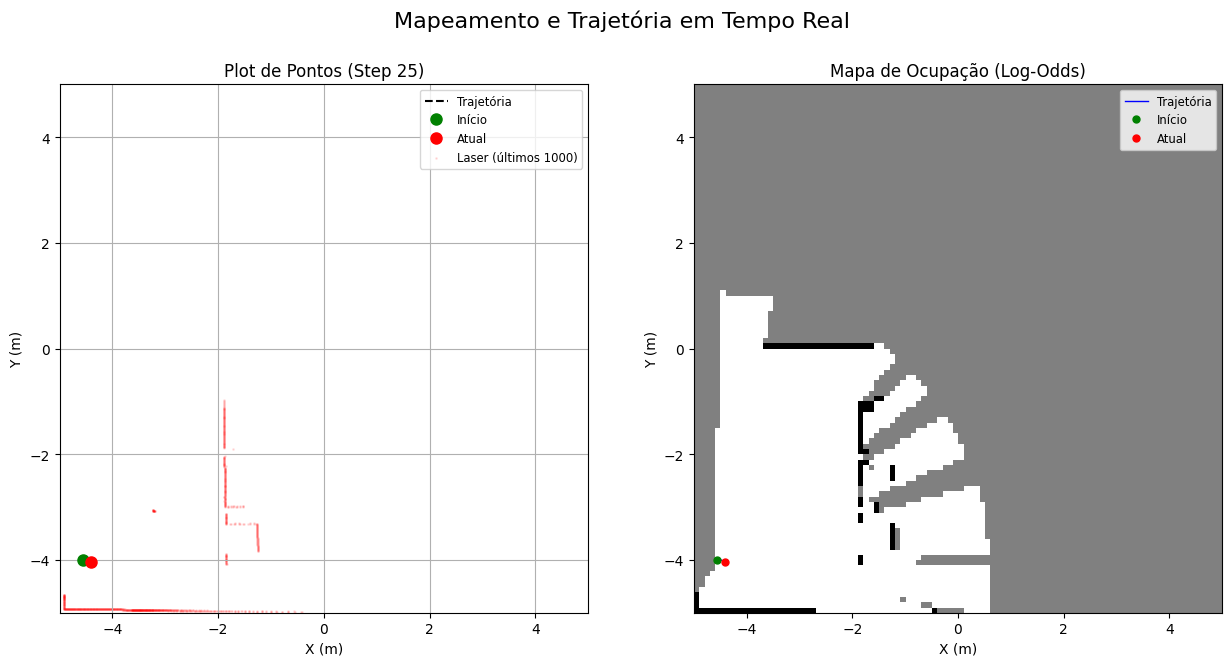

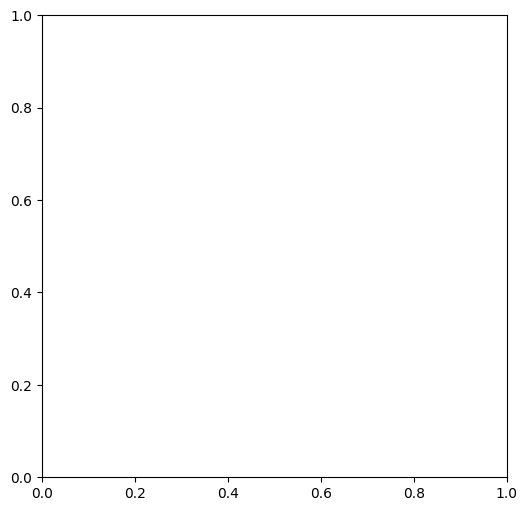

KeyboardInterrupt: 

In [ ]:

import numpy as np
# import matplotlib          # <-- 1. Importe o matplotlib "principal"
# matplotlib.use("Qt5Agg")  # <-- 2. Defina o backend para TkAgg
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import math 
import networkx as nx
import numpy as np
from skimage.draw import line
from matplotlib.colors import ListedColormap


# import HokuyoSensorSim
# import controleWallFollowing

from coppeliasim_zmqremoteapi_client import RemoteAPIClient 

def Rz(theta):
  
    return np.array([[ np.cos(theta), -np.sin(theta), 0 ],
                      [ np.sin(theta), np.cos(theta) , 0 ],
                      [ 0            , 0             , 1 ]])


def pixel_to_world(x_px, y_px, img_size=64, world_size=10):
        scale = world_size / img_size
        x_world = ((x_px - img_size/2) * scale)
        y_world = (-(y_px - img_size/2) * scale) 
        return x_world, y_world

# mexendo atualmente
LOG_ODDS_MIN = -10.0
LOG_ODDS_MAX = 10.0

# --- PARÂMETROS DO MAPA ---
MAP_RESOLUTION = 0.1  # 10 cm por célula (problema quando muda a resolucao)
MAP_SIZE_X = 10.0      # metros
MAP_SIZE_Y = 10.0      # metros
MAP_ORIGIN_X = -5.0    # Canto inferior esquerdo X
MAP_ORIGIN_Y = -5.0    # Canto inferior esquerdo Y
nrows = int(MAP_SIZE_Y / MAP_RESOLUTION)
ncols = int(MAP_SIZE_X / MAP_RESOLUTION)
MAX_SCAN_DISTANCE = 5.0

# Valores de Log-Odds
# l_occ = 0.9
# l_free = -0.4
LOG_ODDS_MIN = -5.0
LOG_ODDS_MAX = 5.0



plt.ion() # Ligar modo interativo
# Criar uma figura com 2 subplots (1 linha, 2 colunas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle("Mapeamento e Trajetória em Tempo Real", fontsize=16)
cmap_vis = ListedColormap(['#808080', '#FFFFFF', '#000000'])
N_LASER_POINTS_PLOT = 1000 # Limite de pontos de laser para plotar (performance)
map_extent = [MAP_ORIGIN_X, MAP_ORIGIN_X + MAP_SIZE_X, 
              MAP_ORIGIN_Y, MAP_ORIGIN_Y + MAP_SIZE_Y]


# -----------------------
# Setup CoppeliaSim (exemplo)
# -----------------------
client = RemoteAPIClient()
sim = client.require("sim")
sim.stopSimulation()
time.sleep(0.2)
sim.startSimulation()
sim.setStepping(True)

robotname = "kobuki"
robot = sim.getObject(f'/{robotname}')
l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')
hokuyo = HokuyoSensorSim(sim, f"/{robotname}/fastHokuyo")  # seu wrapper

# funcoes a verificar
world = pixel_to_world(30,34,100,10)
goal_position = np.array([world[0], world[1]])

# -----------------------
# Config mapa / constantes
# -----------------------
map_size_m = 10.0
cell_size = 0.1                      # m por célula
ncols = int(map_size_m / cell_size)  # cols = eixo X
nrows = int(map_size_m / cell_size)  # rows = eixo Y
grid_origin = np.array([-map_size_m/2, -map_size_m/2])  # world coord do canto inferior esquerdo da célula (0,0)


L = 0.381  
r = 0.0975 

hist = []            
laser_global = []    

# log-odds map: shape (nrows, ncols) -> index como [row, col] = [y, x]
log_odds_map = np.zeros((nrows, ncols))
last_seen = np.zeros_like(log_odds_map)


# colormap: 0=desconhecido(gray), 1=livre(white), 2=ocupado(black)
cmap = ListedColormap(["gray", "white", "black"])

# -----------------------
# Loop principal (visualização em metros)
# -----------------------
plt.ion()
fig, ax = plt.subplots(figsize=(6,6))

robot_path_world = []  # lista de (x,y) world coordinates

LIMITE_TEMPO_SIM = 20 * 60
step = 0

controle = Controlador()


while sim.getSimulationState() != sim.simulation_stopped:
    current_sim_time = sim.getSimulationTime()

    sim.step()

    step +=1

    
    if step > 10000:
        print(f"Tempo limite de {LIMITE_TEMPO_SIM}s atingido. Parando a simulação.")
        break

    pos = sim.getObjectPosition(robot, sim.handle_world)
    ori = sim.getObjectOrientation(robot, sim.handle_world)
    
    
    hist.append([pos[0], pos[1]])
    
    laser_data = hokuyo.getSensorData() # Retorna [ângulo, dist]
    laser_global.extend(transform_laser_to_global(laser_data, pos, ori))

    robot_pos = [pos[0], pos[1], ori[2]]
    
    
    laser_data_swapped = [[d, a] for a, d in laser_data]
        
    log_odds_map, last_seen = update_map_log_odds(
        log_odds_map,
        robot_pos,
        laser_data_swapped,
        step,
        last_seen
    )
    
    # salvar rastro em coords do mundo
    robot_path_world.append((robot_pos[0], robot_pos[1]))
    wl, wr =  controle.controle_wall_following_com_escape(sim, robot, laser_data, r, L)
    
    # wl, wr =  controle_campos(world, goal_position, np.array([pos[0], pos[1]]), ori, laser_data, r, L)
    sim.setJointTargetVelocity(l_wheel, wl)
    sim.setJointTargetVelocity(r_wheel, wr)

    if step % 25 == 0:
        
        ax1.clear()
        ax2.clear()

        
        if hist:
            x, y = zip(*hist)
            ax1.plot(x, y, '--k', label="Trajetória")
            ax1.plot(x[0], y[0], 'go', markersize=8, label="Início")
            ax1.plot(x[-1], y[-1], 'ro', markersize=8, label="Atual")

        if laser_global:
            points_to_plot = laser_global[-N_LASER_POINTS_PLOT:]
            lx, ly = zip(*points_to_plot)
            ax1.scatter(lx, ly, s=1, c='r', alpha=0.1, label=f"Laser (últimos {N_LASER_POINTS_PLOT})")

        ax1.set_title(f"Plot de Pontos (Step {step})")
        ax1.set_xlabel("X (m)")
        ax1.set_ylabel("Y (m)")
        ax1.set_aspect('equal')
        ax1.legend(fontsize='small')
        ax1.grid(True)

        ax1.set_xlim(MAP_ORIGIN_X, MAP_ORIGIN_X + MAP_SIZE_X)
        ax1.set_ylim(MAP_ORIGIN_Y, MAP_ORIGIN_Y + MAP_SIZE_Y)


        # Plot 2 OCCUPANCY GRID
        
        prob = 1.0 / (1.0 + np.exp(-log_odds_map)) 


        grid_vis = np.zeros_like(prob, dtype=np.uint8)
        grid_vis[prob < 0.45] = 1 
        grid_vis[prob > 0.55] = 2 
                  
        ax2.imshow(grid_vis, origin='lower', cmap=cmap_vis, extent=map_extent, vmin=0, vmax=2)

        if hist:
            xs, ys = zip(*hist)
            ax2.plot(xs, ys, color='blue', linewidth=1, label="Trajetória")
            ax2.plot(xs[0], ys[0], 'go', markersize=5, label="Início")
            ax2.plot(xs[-1], ys[-1], 'ro', markersize=5, label="Atual")

        ax2.set_title("Mapa de Ocupação (Log-Odds)")
        ax2.set_xlabel("X (m)")
        ax2.set_ylabel("Y (m)")
        ax2.set_aspect('equal')
        ax2.legend(fontsize='small')
        
        plt.pause(0.01) 
        


# parar sim
sim.stopSimulation()
print('Program ended')

# --- MODIFICADO: LÓGICA DE PLOTAGEM FINAL ---

# Fechar a janela interativa (fig) que estava aberta
plt.close(fig) 
plt.ioff() # Garantir que estamos em modo não-interativo para salvar

print("Gerando plots finais com 600 dpi...")

# --- Plot 1: Scatter Plot (Todos os pontos) ---
fig1, ax1 = plt.subplots(figsize=(10, 10)) # Nova figura

if hist:
    x, y = zip(*hist)
    # Linha da trajetória mais fina para não poluir
    ax1.plot(x, y, '--k', label="Trajetória", linewidth=0.5)
    ax1.plot(x[0], y[0], 'go', markersize=8, label="Início")
    ax1.plot(x[-1], y[-1], 'ro', markersize=8, label="Fim")

# --- MODIFICADO: Plotar TODOS os pontos de laser ---
if len(laser_global) > 0:
    lx, ly = zip(*laser_global)
    # Usar alpha baixo e 's' pequeno para ver a densidade
    ax1.scatter(lx, ly, s=1, c='r', alpha=0.05, label="Laser (Todos os Pontos)")

ax1.legend()
ax1.set_xlabel("X [m]")
ax1.set_ylabel("Y [m]")
ax1.grid(True)
ax1.set_title("Plot de Pontos do Laser (Completo)")
ax1.set_aspect('equal')
# Garantir que os limites do mapa estão corretos
ax1.set_xlim(MAP_ORIGIN_X, MAP_ORIGIN_X + MAP_SIZE_X)
ax1.set_ylim(MAP_ORIGIN_Y, MAP_ORIGIN_Y + MAP_SIZE_Y)

# Salvar figura 1
try:
    fig1.savefig("scatter_plot_final.png", dpi=600, bbox_inches='tight')
    print("... 'scatter_plot_final.png' salvo com 600 dpi.")
except Exception as e:
    print(f"Erro ao salvar scatter plot: {e}")
plt.close(fig1) # Fechar para liberar memória


# --- Plot 2: Mapa de Ocupação Final ---
fig2, ax2 = plt.subplots(figsize=(10, 10)) # Nova figura

# Recalcular o grid visual (copiado de dentro do loop)
prob = 1.0 / (1.0 + np.exp(-log_odds_map)) 
grid_vis = np.zeros_like(prob, dtype=np.uint8) # 0 = desconhecido
grid_vis[prob < 0.45] = 1 # 1 = livre (branco)
grid_vis[prob > 0.55] = 2 # 2 = ocupado (preto)
          
ax2.imshow(grid_vis, origin='lower', cmap=cmap_vis, extent=map_extent, vmin=0, vmax=2)

if hist:
    xs, ys = zip(*hist)
    ax2.plot(xs, ys, color='blue', linewidth=0.5, label="Trajetória")
    ax2.plot(xs[0], ys[0], 'go', markersize=5, label="Início")
    ax2.plot(xs[-1], ys[-1], 'ro', markersize=5, label="Fim")

ax2.set_title("Mapa de Ocupação Final Explorado")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
ax2.set_aspect('equal')
ax2.legend()

# Salvar figura 2
try:
    fig2.savefig("occupancy_grid_final.png", dpi=600, bbox_inches='tight')
    print("... 'occupancy_grid_final.png' salvo com 600 dpi.")
except Exception as e:
    print(f"Erro ao salvar o mapa de ocupação: {e}")
plt.close(fig2) # Fechar para liberar memória

print("Plots finais salvos com sucesso. Script terminado.")
# O plt.show() foi removido, o script agora salva e termina.
# --- FIM DA MODIFICAÇÃO ---